# Prueba negocio Data analisis con data set publico

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/9. Sales-Data-Analysis.csv"
df_Negocio = pd.read_csv(file_path)
df_Negocio.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,07-11-2022,Fries,3.49,573.07,Online,Gift Card,Tom Jackson,London
1,10453,07-11-2022,Beverages,2.95,745.76,Online,Gift Card,Pablo Perez,Madrid
2,10454,07-11-2022,Sides & Other,4.99,200.40,In-store,Gift Card,Joao Silva,Lisbon
3,10455,08-11-2022,Burgers,12.99,569.67,In-store,Credit Card,Walter Muller,Berlin
4,10456,08-11-2022,Chicken Sandwiches,9.95,201.01,In-store,Credit Card,Walter Muller,Berlin


#1. Hipotesis : Hay porductos que generan la mayor parte del ingreso
---
( Con esto podemos saber si el cliente cree que todo vende igual)

In [ ]:
df_Negocio['ingreso'] = df_Negocio['Price'] * df_Negocio['Quantity']

In [ ]:
ventas_producto = df_Negocio.groupby("Product")['ingreso'].sum().sort_values(ascending=False)

ventas_producto.head(10)

,ingreso
Product,
Burgers,376999.8069
Fries,125674.2903
Chicken Sandwiches,114641.6950
Beverages,103200.2630
Sides & Other,48999.8040


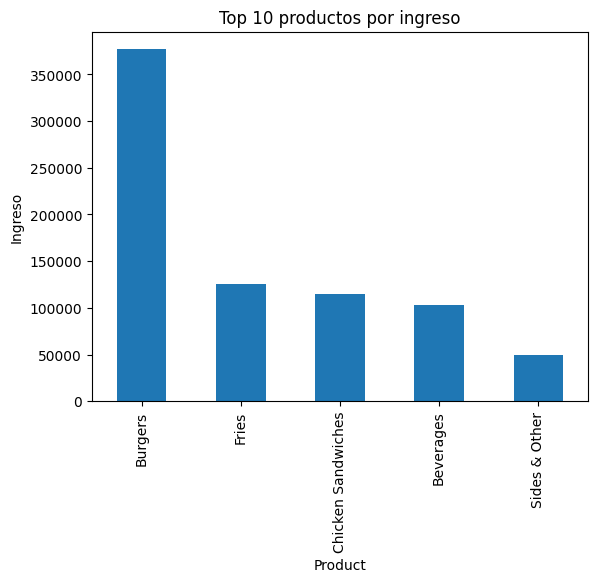

In [ ]:
import matplotlib.pyplot as plt  # Vizualicacion ingreos por productos

ventas_producto.head(10).plot(kind='bar')
plt.title("Top 5 productos por ingreso")
plt.ylabel("Ingreso")
plt.show()

#Interpretacion de resultados
* ¿Qué productos están arriba?
Los productos que más generan ingreso son:

Burgers (~48.99%)
Fries (~16.33%)
Chicken Sandwiches (~14.89%)


* ¿Cuántos productos generan la mayoría del ingreso?
Solo 3 categorías generan ~80.2% del ingreso total


* ¿Hay mucha diferencia entre el 1° y el 10°?
Sí hay diferencia importante:

Burgers = 48%
Sides and other = 6.3%

 El producto principal genera casi 5 veces más que el último

In [ ]:
total_ingresos = ventas_producto.sum()    # Validacion 80/20

porcentaje = (ventas_producto / total_ingresos) * 100

acumulado = porcentaje.cumsum()

resultado = pd.DataFrame({
    'ingreso': ventas_producto,
    '% individual': porcentaje,
    '% acumulado': acumulado
})

resultado.head(10)

,ingreso,% individual,% acumulado
Product,,,
Burgers,376999.8069,48.991818,48.991818
Fries,125674.2903,16.331605,65.323423
Chicken Sandwiches,114641.6950,14.897899,80.221322
Beverages,103200.2630,13.411064,93.632385
Sides & Other,48999.8040,6.367615,100.000000


# Interpretacion Resultados

“El negocio presenta una concentración importante de ingresos en pocas categorías, lo cual es positivo para enfocar esfuerzos, pero también representa un riesgo debido a la alta dependencia de estos productos clave.” 📈


3 categorías = 80%

💥 Esto indica:

✔ Hay concentración (normal) Dependencia alta

 Si burgers falla:

Baja TODO el ingreso

2. Poca diversificación

 El negocio no está equilibrado

3. Vulnerabilidad

 Problemas en:

proveedores
precio
demanda
⚠ Pero también dependencia

 ¿Qué sería lo “ideal”?

No hay una regla perfecta, pero:

🟢 Balance saludable

Top productos → 50–70%
Resto → 30–50%

Tienes productos fuertes
Pero no dependes de pocos

#2. Hipotesis : Hay porductos que se venden mucho mas pero no generan tanto ingreso
---
( Con esto podemos saber  que productos  parecen buenos porque venden mucho pero en realidad no generan el dinero suficente)

In [ ]:
df_Negocio['ingreso'] = df_Negocio['Price'] * df_Negocio['Quantity']

cantidad = df_Negocio.groupby('Product')['Quantity'].sum()
ingresos = df_Negocio.groupby('Product')['ingreso'].sum()

comparacion = pd.concat([cantidad, ingresos], axis=1)
comparacion.columns = ['cantidad', 'ingreso']
comparacion.head(10)

,cantidad,ingreso
Product,,
Beverages,34983.14,103200.2630
Burgers,29022.31,376999.8069
Chicken Sandwiches,11135.92,114641.6950
Fries,32034.34,125674.2903
Sides & Other,9819.60,48999.8040


Detectamos pratones como :

🟢 Caso 1:
Mucha cantidad
Poco ingreso

 Problema:
💥 Precio bajo o mala estrategia

🟢 Caso 2:
Poca cantidad
Mucho ingreso

 Oportunidad:
💥 Producto premium

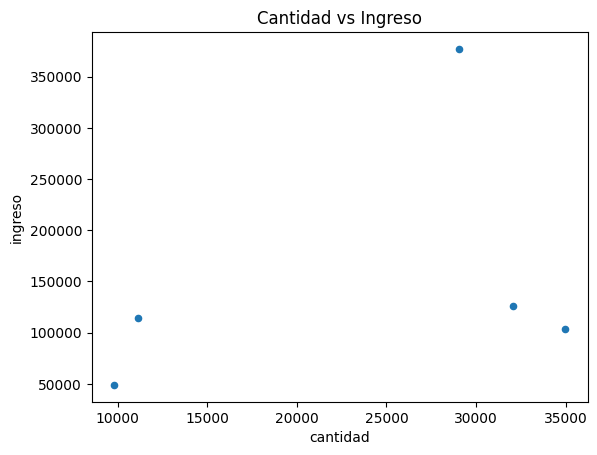

In [ ]:
import matplotlib.pyplot as plt             #Grafica de Comparacion

comparacion.plot(kind='scatter', x='cantidad', y='ingreso')
plt.title("Cantidad vs Ingreso")
plt.show()

#Interpretacion Resultados

* Se vende mucho pero no genera tanto?

Productos identificados:
Beverages
Fries

📊 Datos:

Beverages → MUCHA cantidad (~34,983) pero bajo ingreso (~103,200)


Fries → MUCHA cantidad (~32,034) pero ingreso bajo (~125,674)

Se identificaron productos con alto volumen de ventas pero bajo impacto en ingresos, lo que indica que su precio es bajo o que no están contribuyendo significativamente a la rentabilidad del negocio.”




* Genera mucho ingreso con pocas ventas?
SÍ

🟢 Producto identificado:
Chicken Sandwiches
📊 Datos:

Cantidad relativamente baja (~11,135)

Pero ingreso ALTO (~114,641)


Existen productos que, a pesar de tener menor volumen de ventas, generan un alto ingreso, lo que sugiere que tienen un mayor valor o precio.”

# Recomendaciones :
Para productos de alto volumen y bajo ingreso (Beverages, Fries)

👉 Opciones:

Subir precio

Hacer combos

Reducir costo

Revisar si vale la pena mantenerlos

🟢 Para productos de alto ingreso (Chicken Sandwiches)

👉 Acciones:

Promocionarlos más

Aumentar visibilidad

Analizar si se pueden vender más


“El negocio está priorizando volumen sobre valor en ciertos productos, lo que puede estar limitando el crecimiento de ingresos.”

🚀  CONEXIÓN CON LA SIGUIENTE VENTA

“Sería importante analizar los costos de estos productos, ya que si además tienen costos altos, podrían estar generando pérdidas.”

# 3. Hipotesis : Hay dias donde se venden mas que otros

Hay momentos del dia donde se venden mas ( esta hipotesis se usa solo si el data set que tenemos horarios y asi podemos identificar en que horario se venden mas)
---
( Esto es importante  porque impacta  en Personal , Produccion , Costos , Ventas Con esto podemos Optimizar el negocio)

In [ ]:
df_Negocio['ingreso'] = df_Negocio['Price'] * df_Negocio['Quantity']

<Axes: xlabel='Date'>

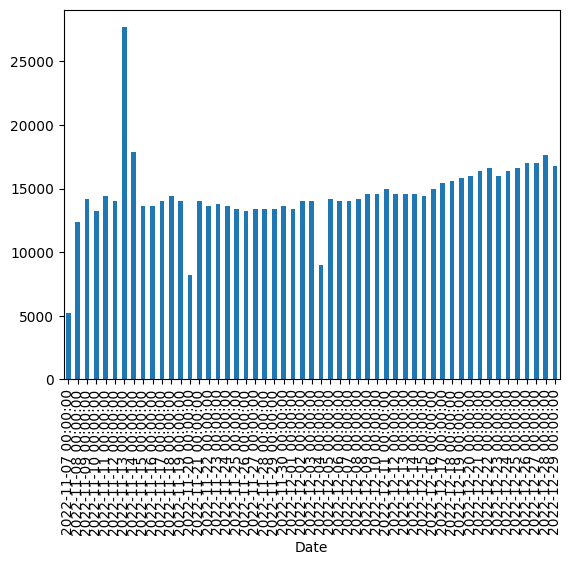

In [ ]:
df_Negocio['Date'] = pd.to_datetime(df_Negocio['Date'], format="%d-%m-%Y")

ventas_dia = df_Negocio.groupby('Date')['ingreso'].sum()

ventas_dia.plot(kind='bar')

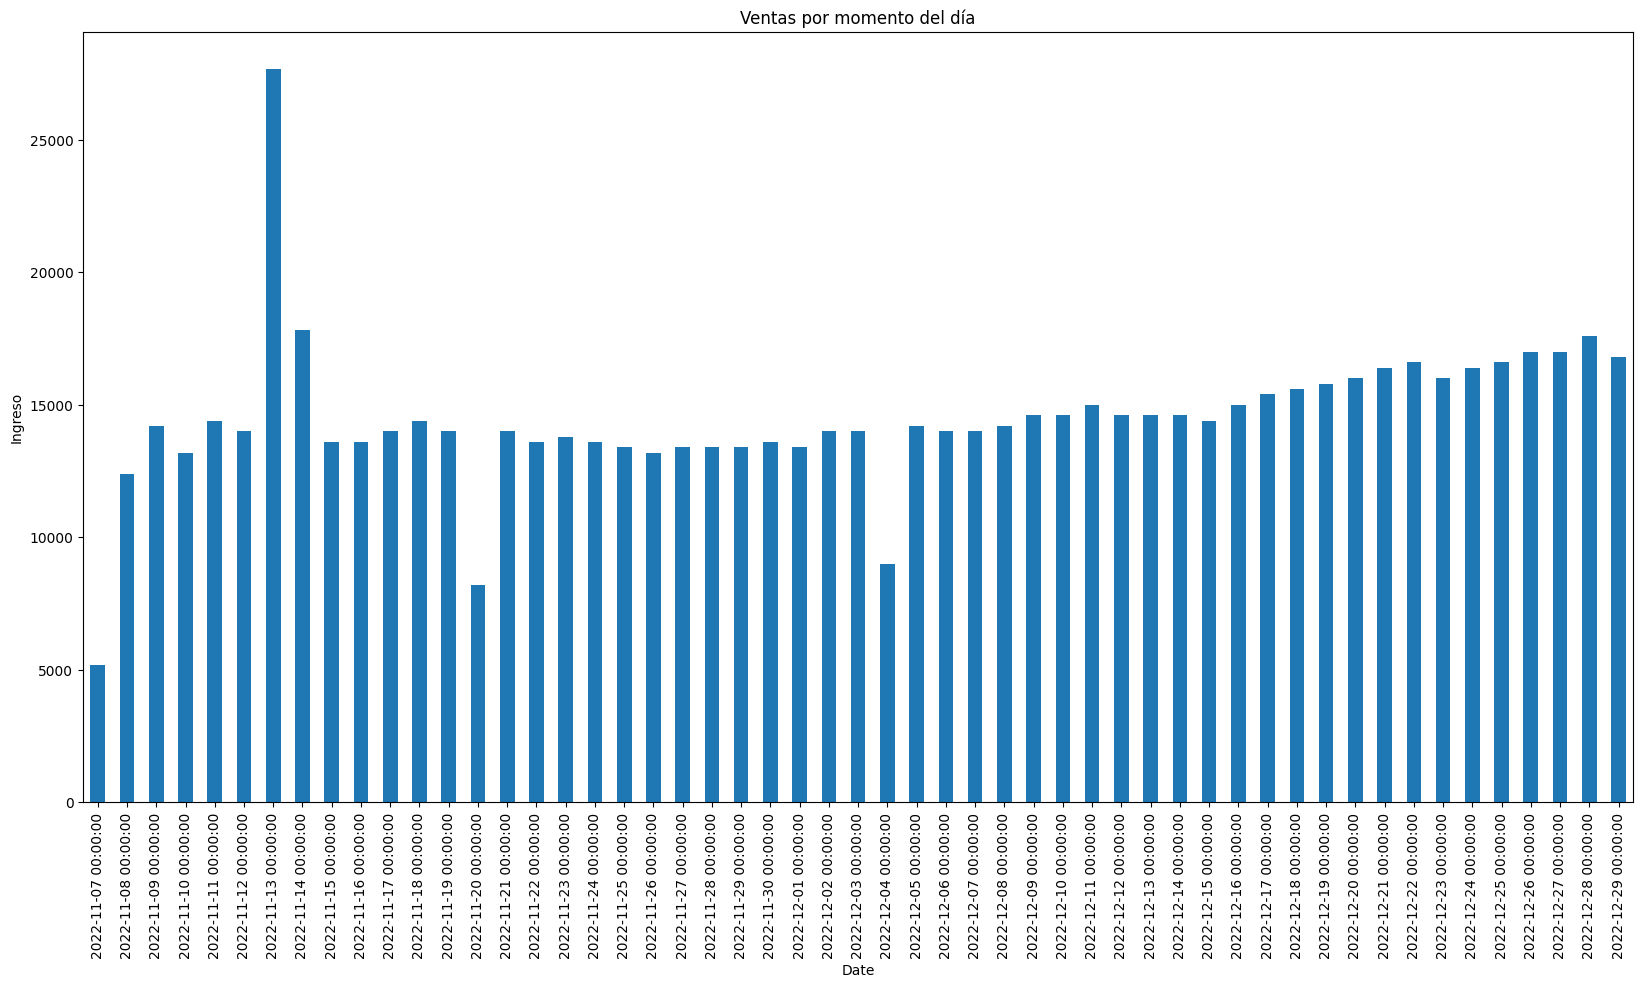

In [ ]:
import matplotlib.pyplot as plt  #Visualizacion
plt.figure(figsize=(20, 10))
ventas_dia.plot(kind='bar')
plt.title("Ventas por momento del día")
plt.ylabel("Ingreso")
plt.show()

#Interpetacion Resultados
* ¿Cuál es el momento con más ingreso?


 En la gráfica se ve que hay uno o dos días pico (alrededor del 13–14 del mes aprox.)

“El mayor ingreso se concentra en ciertos días específicos, donde las ventas alcanzan picos superiores al promedio.


* ¿Cuál es el más bajo?

El día más bajo:

 Aproximadamente ≈ 7

 Se ve claramente una caída fuerte en comparación con el resto


 “Se identifican días con ingresos significativamente bajos en comparación con el promedio general.”

* ¿Hay mucha diferencia entre ellos?

SÍ, y es MUY importante

 Datos:
Máximo ≈ 28,000
Mínimo ≈ 5,100

 Diferencia ≈ 5 veces más

 “Existe una alta variabilidad en los ingresos diarios, lo que indica que las ventas no son consistentes a lo largo del tiempo


#Interpretacion normal
“El comportamiento de ventas muestra variaciones importantes entre días, con picos y caídas significativas. Esto sugiere que la demanda no es uniforme y podría estar influenciada por factores externos como el día de la semana, promociones o comportamiento del cliente.”



 Esto significa:

Hay días MUY buenos
Hay días MUY malos
El negocio NO es estable

# Recomendaciones

Para días altos 📈

 Acción:

Aumentar inventario

Más personal

No perder ventas

 Para días bajos 📉

 Acción:

Promociones

Descuentos

Estrategias (2x1, combos)


“El negocio tiene oportunidades claras de optimización al identificar qué factores están impulsando los días de mayor venta y replicarlos en los días de baja demanda.”

Se recomienda analizar si estos picos corresponden a fines de semana, días festivos o estrategias comerciales específicas para poder replicar estos resultados.

# 4. Hipotesis : El metodo de pago influye en los ingresos

---
( Esto nos ayuda a entender como prefieren a pagar los clientes , estas limitado en ventas de pago y oportunidades de mejorar la experiencia )

In [ ]:
df_Negocio['ingreso'] = df_Negocio['Price'] * df_Negocio['Quantity']

In [ ]:
metodo_pago = df_Negocio.groupby('Payment Method')['ingreso'].sum().sort_values(ascending=False)

metodo_pago

,ingreso
Payment Method,
Credit Card,361715.0265
Cash,239200.2355
Gift Card,168600.5972


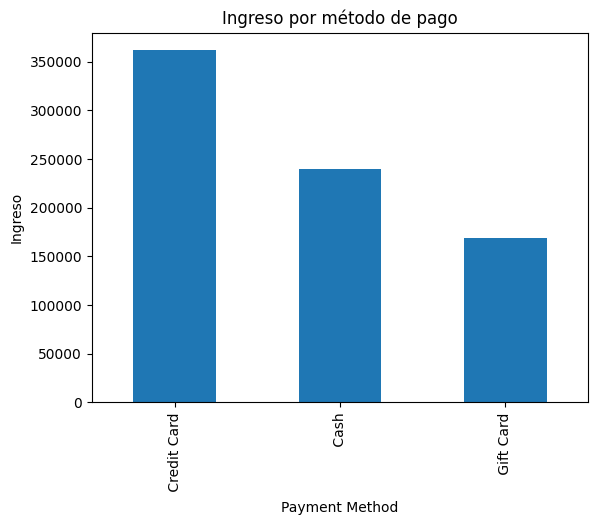

In [ ]:
import matplotlib.pyplot as plt

metodo_pago.plot(kind='bar')
plt.title("Ingreso por método de pago")
plt.ylabel("Ingreso")
plt.show()

#Interpretacion Resultados
1. Qué método genera más ingreso?
Credit Card (tarjeta de crédito)

📊 Dato:

Credit Card ≈ 361,715

“El método de pago que genera mayor ingreso es la tarjeta de crédito, lo que indica una fuerte preferencia de los clientes por pagos electrónicos.”


 2. ¿Cuál es el menos utilizado?

Gift Card

📊 Dato:

Gift Card ≈ 168,600


“El método menos utilizado es la tarjeta de regalo, lo que sugiere que su uso es limitado o que no está siendo promovido adecuadamente.”


 3. ¿Hay mucha diferencia entre ellos?

📊 Comparación:

Credit Card ≈ 361,715
Gift Card ≈ 168,600

 Diferencia ≈ casi el doble

#Detectar Perdidas

(En este data set no contamos con costo entonces se van a simular que son entre el 50o 80 porcineto del precio del producto)

In [ ]:
import numpy as np

# Simular costo entre 50% y 80%
df_Negocio['costo'] = df_Negocio['Price'] * np.random.uniform(0.8, 1.2, size=len(df_Negocio))

In [ ]:
df_Negocio['ingreso'] = df_Negocio['Price'] * df_Negocio['Quantity']
df_Negocio['costo_total'] = df_Negocio['costo'] * df_Negocio['Quantity']
df_Negocio['utilidad'] = df_Negocio['ingreso'] - df_Negocio['costo_total']

In [ ]:
perdidas = df_Negocio.groupby('Product')['utilidad'].sum().sort_values()

perdidas.head(10)

,utilidad
Product,
Sides & Other,-1034.204859
Beverages,516.511205
Chicken Sandwiches,1230.906290
Burgers,1263.941988
Fries,1662.248392


<Axes: xlabel='Product'>

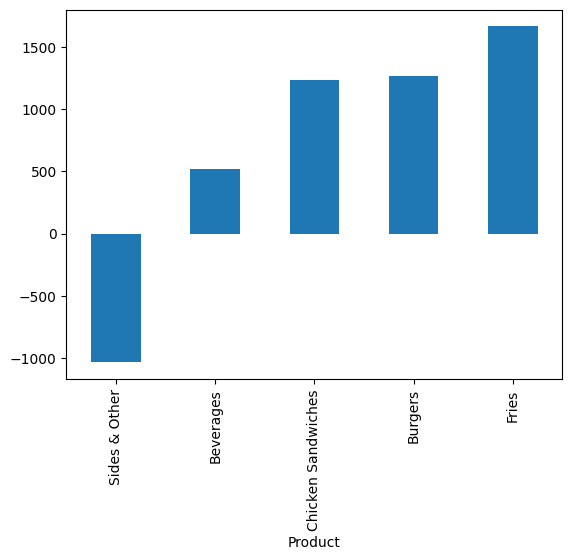

In [ ]:
perdidas.head(10).plot(kind='bar')

# Margen para ver que prodcuto es mas eficiente

In [ ]:
margen = df_Negocio.groupby('Product')['utilidad'].sum() / df_Negocio.groupby('Product')['ingreso'].sum()
margen

,0
Product,
Beverages,0.005005
Burgers,0.003353
Chicken Sandwiches,0.010737
Fries,0.013227
Sides & Other,-0.021106


# Interpetacion Margen

“El análisis de márgenes revela que la categoría ‘Sides & Other’ presenta un margen negativo, lo que indica que está generando pérdidas para el negocio. Adicionalmente, el resto de los productos muestran márgenes muy bajos, lo que sugiere una rentabilidad limitada.”

Acciones Recomendadas
1. Sides & Other (CRÍTICO)

 Acciones:

Subir precio

Reducir costos

Eliminar producto

 2. Productos con margen bajo

 Acciones:

Ajustar precios

Optimizar insumos

Revisar proveedores

 3. Estrategia general


“Mejorar margen global del negocio”


“El negocio presenta una estructura de rentabilidad débil, con márgenes reducidos en la mayoría de los productos y pérdidas en categorías específicas, lo que representa un riesgo para la sostenibilidad financiera.”